Projet realise par: Aissat Mohamed Moncef

Chargement des données : 

In [25]:
import pandas as pd
pd.set_option("display.max_rows", None)   
pd.set_option("display.max_columns", None) 
data = pd.read_csv("sentiment_comments.csv")
print(data)

       Unnamed: 0                                               text  label
0               0       يا سي كريم الرئيس الذى تشتكى له هو أصله معين      1
1               1  حتى السعودية قاتلكم ماكمش عرب،واش بقا يا بعاصي...      0
2               2                              Thbliiii bravo souade      2
3               3          تحيالي ناس بن يزقن و لقصور في الغيبة 🌹🇩🇿🤣      2
4               4  انتم اغبياء او تتغابوا هي تتكلم بالانجليزية و ...      0
5               5  نستعرف بالضحية فايق الله يبارك صورهم في وقت حر...      2
6               6  مدابينا نتعرفو على الامراض واسبابها شكرا ليكم ...      2
7               7  هذا الكلام افهم جيدا معناه وافهمه .فقط جملة وا...      2
8               8  Marete rajale matatek9mesiche hadake eldawere ...      2
9               9    تطوان فيها الأمازيغ 😂 بنقزديرة اش كاتخور هه‍ههه      0
10             10  علاش الجزائري كي يتزوج مع جزائرية مايديرلهاش ه...      0
11             11                                شكون جاي هنا للميمز      1
12          

Nettoyage des données : 
- Suppression de la ponctuation avec re.sub.
- Conversion en minuscules pour uniformiser.
- Suppression des stopwords.
- Stemming avec ISRIStemmer.
- Sauvegarde du dataset nettoyé dans sentiment_comments_cleaned.csv.

In [26]:
import re
import pandas as pd
from nltk.stem.isri import ISRIStemmer

data = pd.read_csv("sentiment_comments.csv")

if "text" not in data.columns:
    raise ValueError("La colonne 'text' est absente du dataset.")

data["text"] = data["text"].astype(str).apply(lambda x: re.sub(r"[^\w\s]", "", x))

data["text"] = data["text"].str.lower()

stop_words = [
    "في","أو","هذا","كي","على","له","مع","لك","هيا","فيه","ما","أنا","غير","لها","من","هاك","هذه","لا","لهم","يا","لنا","فيها","أنت","لي","بعد","عن","هي","عليه","حتى","بعض","هكذا","عليك","أكثر","إن","ها","أما","أنى","أين",
    "بكم","كم","و","راك","او","واحد","ݣاع","تاع","باش","واش","دروك","كيما","انت","كاين","الِّي","قال","الي","الّي","الى","معي","كنت","هيّا","دوك","بيك","حنا","بيه","أني","دروكَ","الٍّي","فيك","كيفاه","أخر","خاطر","ياك","تاعك","لنّا","هكّذا","هديك","عندك","فْي","أُو","نت","هيَّا","هَذا","مْنْ","ثْمّْ","انا","رانا","شنوأ","وشنو","ألي","أنايا","اي","ليك","راه","بْلّي","مْشْ","تسمًّا","أكيما","مْعَ","صّحا","وْ","الٍٍي","عْلى","اهْيَا","كاش","هذاك","يط","ليهم","أش","أَه","أٌو","هكَّا","أنتَ","إه","هيَا","لنَّا","هَّاكَ","هَاك","هكّا","بيَّ","هُو","اكثر","معه","حتَّى","هَيَا","أيْوَ","لهذيك","هوّ","مْعَكْ","لّه","اش","ا","آه","آها","آي","أف","أقل","ألا","أم","أن","أنتم","أنتما","أنتن","أولئك","أولاء","أوه","أي","أينما","أيها","إذ","إذا","إذما","إذن","إلا","إلى","إليك","إليكم","إليكما","إليكن","إما","إنا","إنما","إنه","إي","إيه","التي","الذي","الذين","اللائي","اللاتي","اللتان","اللتيا","اللتين","اللذان","اللذين","اللواتي",
    "بخ","بس","بك","بكما","بكن","بل","بلى","بما","بماذا","بمن","بنا","به","بها","بهم","بهما","بهن","بي","بيد","بين","تلك","تلكم","تلكما","ته","تي","تين","تينك","ثم","ثمة","حاشا","حبذا","حيث","حيثما","حين","خلا","دون","ذا","ذات","ذاك","ذان","ذانك","ذلك","ذلكم","ذلكما","ذلكن","ذه","ذو","ذوا","ذواتا","ذواتي","ذي","ذين","ذينك","ريث","سوف","سوى","شتان","عدا","عسى","عل","عما","عند","فإذا","فإن","فلا","فمن","فيم","فيما","قد","كأن","كأنما","كأي","كأين","كذا","كذلك","كل","كلا","كلاهما","كلتا","كلما","كليكما","كليهما","كما","كيت","كيف","كيفما","لئن","لاسيما","لدى","لست","لستم","لستما","لستن","لسن","لسنا","لعل","لكم","لكما","لكن","لكنما","لكي","لكيلا","لم","لما","لن","لهما","لهن","لو","لولا","لوما","ليت","ليس","ليسا","ليست","ليستا","ليسوا","ماذا","متى","مذ","مما","ممن","منذ","منه","منها","مه","مهما","نحن","نحو","نعم","هؤلاء","هاتان","هاته","هاتي","هاتين","هاهنا","هذان","هذي","هذين","هل","هلا","هم","هما","هن","هنا","هناك","هنالك","هو","هيت","هيهات","وإذ","وإذا","وإن","والذي","والذين","ولا","ولكن","ولو","وما","ومن","وهو",
    "ضك","ضرك","ضوك","ضورك","ضكا","ضركا","ضكاتيك","أل","أما","حتى","حنا","هنايا","هناتيك","إمما","ماكاش","ماكان","ماكانش","مكاش","مكان","مكانش","مكاينش","مكاين","ذاك","شغل","الي","نا","نايا","نتي","نتييا","باش","باشيك","بالاك","بالك","بالكي","بعد","بعدا","منبعد","بالي","برك","بززاف","ب","بين","بيننا","بيناتنا","بيناتهم","بينهم","بيناتكم","عالى","عند","عندكم","عندهم","علاش","عليه","عليهم","عليك","عليكم","عليش","ةعليه","ف","في","فيه","فيها","فيهش","فيهم","فيكم","ڨاع","ڨاعتيك","هاذ","هاذو","هاذك","هاك","هاكي","هذ","هذاك","هذديك","هذديكا","هذي","هي","هيي","هييا","هييى","هنا","هنيا","هم","هنا","هو","هوما","ذا","وذا","لا","لى","ن","يه","كاش","كان","كانش","كاين","كاينش","كاينة","كي","كيف","كيفاش","كيما","كل","كننا","كنت","كنتو","كنتوش","لا","لازم","لازمنا","لازمها","لها","لهم","لك","لكم","لو","لها","لهم","لكم","ل","لي","أللي","لنا","لو","ما","مع","معهم","معاكم","معاك","من","مبعد","ممبعد","معاه","معاها","معاهكم","معاهم","معاك","من","مليح","مليحة","تاع","تاعي","تع","ثمما","ثمماتيك","و","واحد","واحدة","واش","وش","واللا","ولا","وين","يا","يعني","زعما"
]

data["text"] = data["text"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

stemmer = ISRIStemmer()
data["text"] = data["text"].apply(
    lambda x: " ".join([stemmer.stem(word) for word in x.split()])
)

data.to_csv("sentiment_comments_cleaned.csv", index=False, encoding="utf-8")

print(data.head(10))


   Unnamed: 0                                               text  label
0           0                        سي كرم رئس الذى شكى اصل عين      1
1           1  سعد قتل اكمش عربواش بقا عاصيص رجعو أصل امازيغي...      0
2           2                              thbliiii bravo souade      2
3           3                             حيل ناس بن يزق قصر غيب      2
4           4                 نتم غبياء تغب كلم انجليزية اضف رجم      0
5           5                    عرف ضحة فيق الل يبر صور وقت حرج      2
6           6     دبي عرفو مرض سبب شكر يكم حصة روع شكر بزف دكتور      2
7           7  كلم فهم جيد عنه فهم فقط جمل غير فكر رئس علم خط...      2
8           8  marete rajale matatek9mesiche hadake eldawere ...      2
9           9                        تطو ازغ بنقزديرة كاتخور ههه      0


Modélisation : grace a la methode TF-IDF.

In [27]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Charger le dataset nettoyé
data = pd.read_csv("sentiment_comments_cleaned.csv")

# Supprimer ou remplacer les valeurs NaN
data["text"] = data["text"].fillna("")   # remplace NaN par une chaîne vide

texts = data["text"].tolist()

# Transformer les textes avec TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(texts)

print("Forme du vecteur TF-IDF :", X.shape)

feature_names = vectorizer.get_feature_names_out()
tfidf_matrix = pd.DataFrame(X.toarray(), columns=feature_names)
print(tfidf_matrix.head())



Forme du vecteur TF-IDF : (50016, 5000)
    10  100  1000  100100  106   11   12  123   13  130   14   15  150   16  \
0  0.0  0.0   0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.0  0.0   0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.0  0.0   0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.0  0.0   0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.0  0.0   0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

    17   18   19  1962   20  200  2017  2018  2019  2020  2021   21   22   23  \
0  0.0  0.0  0.0   0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0  0.0  0.0  0.0   
1  0.0  0.0  0.0   0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0  0.0  0.0  0.0   
2  0.0  0.0  0.0   0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0  0.0  0.0  0.0   
3  0.0  0.0  0.0   0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0  0.0  0.0  0.0   
4  0.0  0.0  0.0   0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0  0.0  0.0  0.0   

Partitionnement des données : 

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv("sentiment_comments_cleaned.csv")

data["text"] = data["text"].fillna("")

texts = data["text"].tolist()
labels = data["label"].tolist()

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

print("Taille train :", len(train_texts))
print("Taille test :", len(test_texts))


Taille train : 40012
Taille test : 10004


Test et évaluation du modèle : via l'option 1 => calcule de similarite et algorithme KNN.
- le modèle compare chaque commentaire aux 5 plus proches voisins et calcule Accuracy et F1‑score.
- la matrice de confusion montre les erreurs par classe, et le rapport détaille précision, rappel et F1‑score.
- comparaison entre prédictions et labels réels, puis export dans un fichier CSV pour étude.

Accuracy : 0.6665333866453419
F1 score : 0.6602579739562586
Le modèle est moyen, des améliorations sont possibles ( 0.7> accuracy >= 0.6).


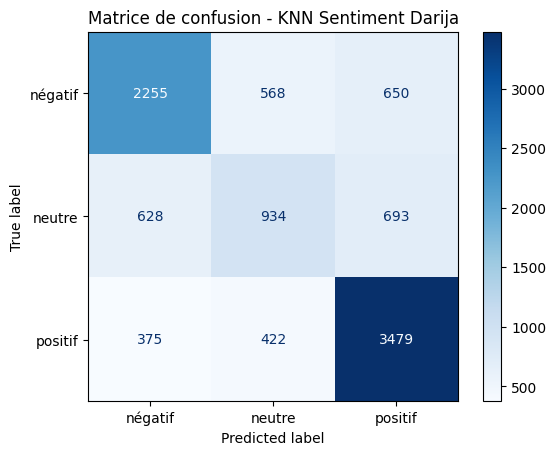


Rapport de classification :

              precision    recall  f1-score   support

     négatif       0.69      0.65      0.67      3473
      neutre       0.49      0.41      0.45      2255
     positif       0.72      0.81      0.76      4276

    accuracy                           0.67     10004
   macro avg       0.63      0.63      0.63     10004
weighted avg       0.66      0.67      0.66     10004

                                                text predicted_label    label
0                        سي كرم رئس الذى شكى اصل عين          neutre   neutre
1  سعد قتل اكمش عربواش بقا عاصيص رجعو أصل امازيغي...         négatif  négatif
2                              thbliiii bravo souade         positif  positif
3                             حيل ناس بن يزق قصر غيب          neutre  positif
4                 نتم غبياء تغب كلم انجليزية اضف رجم          neutre  négatif


In [29]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

knn = KNeighborsClassifier(n_neighbors=5, metric="cosine")
knn.fit(X_train, train_labels)

preds = knn.predict(X_test)

acc = accuracy_score(test_labels, preds)
f1 = f1_score(test_labels, preds, average="weighted")

print("Accuracy :", acc)
print("F1 score :", f1)

if acc >= 0.7:
    print(f"✅ Le modèle est globalement bon (accuracy >= 0.7).")
elif acc >= 0.6:
    print(f"Le modèle est moyen, des améliorations sont possibles ( 0.7> accuracy >= 0.6).")
else:
    print(f"⚠️ Le modèle est faible, il faut l'améliorer (accuracy < 0.6).")

cm = confusion_matrix(test_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["négatif", "neutre", "positif"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion - KNN Sentiment Darija")
plt.show()

print("\nRapport de classification :\n")
print(classification_report(test_labels, preds, target_names=["négatif", "neutre", "positif"]))

sample_data = data.head(1000).copy()   

X_sample = vectorizer.transform(sample_data["text"].tolist())

sample_preds = knn.predict(X_sample)

sample_data.loc[:, "predicted_label"] = sample_preds

label_map = {0: "négatif", 1: "neutre", 2: "positif"}
sample_data["predicted_label"] = sample_data["predicted_label"].map(label_map)
sample_data["label"] = sample_data["label"].map(label_map)

sample_data = sample_data[["text", "predicted_label", "label"]]

sample_data.to_csv("sentiment_comments_sample_predictions.csv", index=False, encoding="utf-8")

print(sample_data.head())
